In [123]:
# Load libraries

import os
import pandas
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy import stats
import sklearn.model_selection
import shutil

# import my extended pySuStaIn model
from apoe4_sustain import ZscoreSustain_APOE4
# import simulation function
from genetics_simulation_utils import simulate_apoe_sustain_dataset #genetics_simulation,


1. Simulate biomarkers using zscore SuStaIn model and a categorical variable: APOE carrier status based on fixed genetic probabilities

In [124]:
# define hyper-parameters of simulation
# Configure dataset dimensions
M_patients = 1000
N_biomarkers = 5

In [125]:
# N_subtypes = 1
# gt_fractions = np.array([1.0])
# W_true_target = np.array([
#     [1/3, 1/3, 1/3],  # Subtype 0: High Category 0 anchor[1/3, 1/3, 1/3]   # Subtype 1: High Category 2 anchor
# ])


In [126]:
N_subtypes = 2
gt_fractions = np.array([0.45, 0.55])


#Define the explicit ground-truth genetic profiles for this sandbox run
W_true_target = np.array([
    [0.80, 0.15, 0.05],  # Subtype 0: High Category 0 anchor
    [0.10, 0.30, 0.60]   # Subtype 1: High Category 2 anchor
])

# # #Uniform case
# # W_true_target = np.array([
# #     [1/3, 1/3, 1/3],  # Subtype 0: High Category 0 anchor
# #     [1/3, 1/3, 1/3]   # Subtype 1: High Category 2 anchor
# # ])


In [127]:
# N_subtypes = 3
# W_true_target = np.array([
#     [0.80, 0.15, 0.05],  # Subtype 0: High Category 0 anchor
#     [0.10, 0.30, 0.60],
#     [0.40, 0.40,0.20] ,  # Subtype 1: High Category 2 anchor
# ])
# gt_fractions = np.array([0.60, 0.30, 0.10])

In [128]:

# Generate the dataset in-memory
df, Z_vals, Z_max, gt_ordering, gt_fractions, W_true = simulate_apoe_sustain_dataset(N = N_biomarkers,              
                                                                            M = M_patients,            # number of observations (e.g. subjects)
                                                                            N_S_gt = N_subtypes,         # number of ground truth subtypes
                                                                            gt_f = gt_fractions,         # could also be None
                                                                            W_true = W_true_target,      # genetic_weights
                                                                            genetic_signal_strength = None # could be 'uniform', 'moderate' or 'strong
                                                                            )
df

Generator(PCG64)


,Biomarker 0,Biomarker 1,Biomarker 2,Biomarker 3,Biomarker 4,gt_subtypes,gt_stages,apoe_status
0,0.0,0.000000,0.000000,0.00,0.000,0,0.0,0
1,0.0,0.000000,0.000000,0.00,0.000,0,0.0,0
2,0.0,0.000000,0.000000,0.00,0.000,0,0.0,0
3,0.0,0.000000,0.000000,0.00,0.000,0,0.0,0
4,0.0,0.000000,0.000000,0.00,0.000,0,0.0,1
...,...,...,...,...,...,...,...,...
995,1.4,0.714286,3.000000,1.50,0.625,2,5.0,2
996,1.5,0.857143,3.181818,2.00,0.750,2,6.0,1
997,5.0,5.000000,5.000000,5.00,5.000,2,16.0,2
998,1.2,0.428571,2.000000,0.75,0.375,2,3.0,2


In [129]:
# # Generate the dataset in-memory
# old function I no longer use
# df, Z_vals, Z_max, gt_ordering, W_true = genetics_simulation(
#     N=N_biomarkers, 
#     M=M_patients, 
#     N_S_gt=N_subtypes, 
#     gt_fractions=gt_fractions, 
#     W_true=W_true_target, 
#     use_midpoints=False, # Set to True if you want to test your supervisor's midpoint variant
#     save=False
# )

# df

In [130]:
# Extract raw arrays for the model execution
BiomarkerNames = [f'Biomarker {i}' for i in range(N_biomarkers)]
X_data = df[BiomarkerNames].values
y_genetics = df['apoe_status'].values

print(f"Generated data matrix shape: {X_data.shape}")
print(f"Generated genetic vector shape: {y_genetics.shape}")

Generated data matrix shape: (1000, 5)
Generated genetic vector shape: (1000,)


In [131]:
N_startpoints = 15
N_S_max = N_subtypes
N_iterations_MCMC = int(1e4)
#output_folder = os.path.join(os.getcwd(), 'MRI_Sustain_5features_all')



In [132]:
dataset_name = 'simulated_data_genetics_model'
output_folder = os.path.join(os.getcwd(), dataset_name)
sustain_input = ZscoreSustain_APOE4(X_data,
                                Z_vals,
                                Z_max,
                                BiomarkerNames,
                                N_startpoints,
                                N_S_max, 
                                N_iterations_MCMC, 
                                output_folder, 
                                dataset_name, 
                                False,
                                apoe4_status = y_genetics,
                                #apoe4_status = gender_status_array,
                                apoe_flag = True, 
                                em_loop_type = 'combined' # or combined ; depending on whether I want to optimise sequences and weights in separate EM or together
                                )

1000 patients initially
 -> Detected 3 unique genetic categories: [0 1 2]
1000 patients with non null apoe4 carrier status
 -> [Genetics Setup] Global cohort background frequencies calculated: [0.413 0.235 0.352]
Running genetic weighted SuStaIn 


Run SuStaIn 

In [133]:
# delete previous pickle files
if os.path.exists(output_folder):
    shutil.rmtree(output_folder)

In [134]:
# make the output directory if it's not already created
if not os.path.isdir(output_folder):
    os.mkdir(output_folder)

In [135]:

samples_sequence,     \
ml_f_EM,            \
ml_subtype,         \
prob_ml_subtype,    \
ml_stage,           \
prob_ml_stage,      \
prob_subtype_stage,         = sustain_input.run_sustain_algorithm()


Failed to find pickle file: /Users/mihaelacroitor/apoe4_informed/simulated_data_genetics_model/pickle_files/simulated_data_genetics_model_subtype0.pickle. Running SuStaIn model for 0 subtype.
Finding ML solution to 1 cluster problem
EM converged in 3 iterations
EM converged in 3 iterations
EM converged in 3 iterations
EM converged in 3 iterations
EM converged in 2 iterations
EM converged in 3 iterations
EM converged in 3 iterations
EM converged in 3 iterations
EM converged in 3 iterations
EM converged in 3 iterations
EM converged in 3 iterations
EM converged in 3 iterations
EM converged in 3 iterations
EM converged in 3 iterations
EM converged in 3 iterations


MCMC Iteration: 100%|██████████| 10000/10000 [00:06<00:00, 1541.60it/s]



   FINAL MODEL SUBTYPE COHORT FRACTIONS
 -> Subtype 1 Cohort Size: 100.00% of dataset

   SUSTAIN GENETIC PRIOR PROFILE (EM MAX LIKELIHOOD)
 -> COHORT BACKGROUND BASELINE : [Cat_0: 0.4130, Cat_1: 0.2350, Cat_2: 0.3520]
------------------------------------------------------------
 -> Subtype 1 Profile Prior : [Cat_0: 0.4130, Cat_1: 0.2350, Cat_2: 0.3520]

Failed to find pickle file: /Users/mihaelacroitor/apoe4_informed/simulated_data_genetics_model/pickle_files/simulated_data_genetics_model_subtype1.pickle. Running SuStaIn model for 1 subtype.
Splitting cluster 1 of 1
Reindexing
 + Resolving 2 cluster problem
EM converged in 4 iterations
EM converged in 2 iterations
EM converged in 16 iterations
EM converged in 3 iterations
EM converged in 3 iterations
EM converged in 20 iterations
EM converged in 3 iterations
EM converged in 4 iterations
EM converged in 17 iterations
EM converged in 3 iterations
EM converged in 3 iterations
EM converged in 16 iterations
EM converged in 3 iterations
EM

MCMC Iteration: 100%|██████████| 10000/10000 [00:15<00:00, 659.91it/s]



   FINAL MODEL SUBTYPE COHORT FRACTIONS
 -> Subtype 1 Cohort Size: 56.59% of dataset
 -> Subtype 2 Cohort Size: 43.41% of dataset

   SUSTAIN GENETIC PRIOR PROFILE (EM MAX LIKELIHOOD)
 -> COHORT BACKGROUND BASELINE : [Cat_0: 0.4130, Cat_1: 0.2350, Cat_2: 0.3520]
------------------------------------------------------------
 -> Subtype 1 Profile Prior : [Cat_0: 0.0618, Cat_1: 0.3212, Cat_2: 0.6170]
 -> Subtype 2 Profile Prior : [Cat_0: 0.8707, Cat_1: 0.1227, Cat_2: 0.0066]



In [154]:
ml_f_EM

array([0.5659082, 0.4340918])

### Proof 1 Does the model recover correct params?

## Does the EM converge to max likelihood?

In [ ]:
s = N_subtypes - 1
pickle_filename_s = output_folder + '/pickle_files/' + dataset_name + '_subtype' + str(s) + '.pickle'
pk = pandas.read_pickle(pickle_filename_s)
ml_likelihood_mat_EM = pk["ml_likelihood_mat_EM"]

ml_genetic_weights_EM = pk["ml_genetic_weights_EM"]
ml_sequence_EM = pk["ml_sequence_EM"]
em_likelihood_histories = pk["em_likelihood_histories"]


In [141]:
# calculate actual max likelihood from simulated parameters
sustainData = sustain_input._AbstractSustain__sustainData
true_max_lik,_ ,_, _, _ = sustain_input._calculate_likelihood(sustainData, gt_ordering,gt_fractions, W_true)
print('True max',true_max_lik)

# find max lik for each startpoint
max_lik_startpoint = np.nanmax(em_likelihood_histories, axis = 0)
print('Max lik for every iter',max_lik_startpoint)

converged_to_true_lik = max_lik_startpoint >= true_max_lik
win_count = converged_to_true_lik.sum()
print(win_count)

True max -7599.777504254151
Max lik for every iter [-7584.35267546 -7584.34892285 -7584.3483424  -7584.35060723
 -7584.34871552 -7584.35220635 -7584.34905693 -7584.35013452
 -7584.34958157 -7584.34843464 -7584.353582   -7584.35262804
 -7584.34811716 -7584.35468244 -7584.3500145 ]
15


In [142]:
# Find avg iterations until convergence across startpoints (all and winning ones)

valid_mask = ~np.isnan(em_likelihood_histories)

# Sum vertically along axis=0 to get an array of 15 integer lengths instantly
iteration_counts_all = np.sum(valid_mask, axis=0)
a_avg_iterations_all = np.mean(iteration_counts_all)


# only for winning trials (where lik reached maximum true_max)
if np.any(converged_to_true_lik):
    # Mask the iteration counts array directly using the boolean success vector
    iteration_counts_win = iteration_counts_all[converged_to_true_lik]
    a_avg_iterations_win = np.mean(iteration_counts_win)
else:
    a_avg_iterations_win = np.nan

print(f"Avg iterations it took to converge across all startingpoints : {a_avg_iterations_all:.1f} iterations ")
print(f"Avg iterations it took to converge across winning startingpoints: {a_avg_iterations_win if np.isnan(a_avg_iterations_win) else f'{a_avg_iterations_win:.1f}'} iterations")

Avg iterations it took to converge across all startingpoints : 18.0 iterations 
Avg iterations it took to converge across winning startingpoints: 18.0 iterations


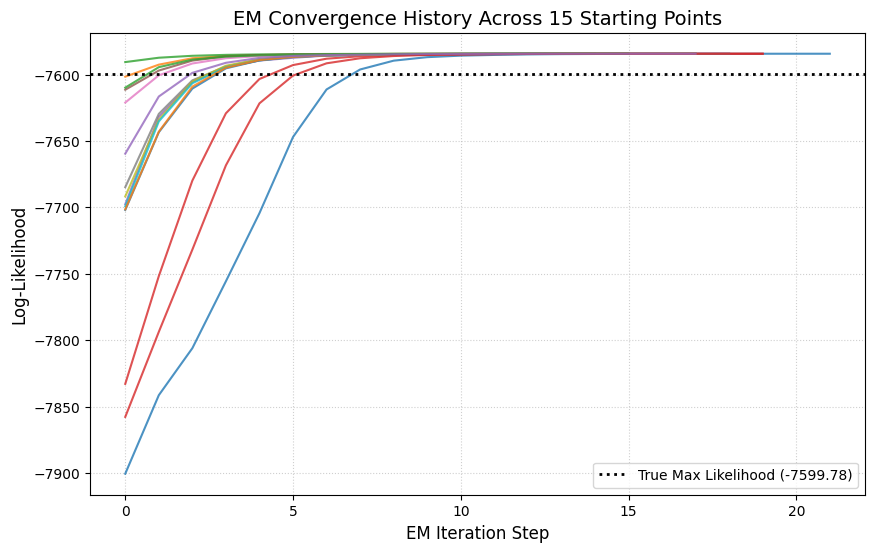

In [143]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Set up the figure size
plt.figure(figsize=(10, 6))

# 2. Plot the array directly
# Matplotlib plots each column (startpoint) as a separate colored line
plt.plot(em_likelihood_histories, linewidth=1.5, alpha=0.8)

# 3. Add your ground-truth maximum likelihood as a horizontal dotted line
# 'ls=":"' makes it dotted, 'color="black"' ensures high contrast, 'zorder=5' keeps it on top
plt.axhline(y=true_max_lik, color="black", linestyle=":", linewidth=2, label=f"True Max Likelihood ({true_max_lik:.2f})")


# 4. Add styling and descriptive labels
plt.xlabel("EM Iteration Step", fontsize=12)
plt.ylabel("Log-Likelihood", fontsize=12)
plt.title(f"EM Convergence History Across {em_likelihood_histories.shape[1]} Starting Points", fontsize=14)

plt.legend()
# 4. Clean up the grid presentation
plt.grid(True, linestyle=":", alpha=0.6)

# 5. Show the plot
plt.show()

In [144]:
# compare estimated vs true params
print("True seq", gt_ordering)
print("Estimated seq", ml_sequence_EM)
print("Estimated fractions",ml_f_EM)
print("True genetic weights",W_true_target)
print("Estimated genetics",ml_genetic_weights_EM)

True seq [[ 1.  2.  4.  3.  0.  8.  5.  9. 10.  7. 14. 13.  6. 12. 11.]
 [ 0.  2.  7.  3. 12.  8.  1.  4.  9.  6.  5. 11. 13. 14. 10.]]
Estimated seq [[ 0.  2.  3.  7.  1. 12.  8.  4.  9.  6.  5. 11. 13. 14. 10.]
 [ 2.  1.  4.  3.  0.  8.  5.  9.  7. 10. 14. 13.  6. 12. 11.]]
Estimated fractions [[0.5659082  0.5659082  0.56738393 ... 0.53280101 0.53280101 0.53280101]
 [0.4340918  0.4340918  0.43261607 ... 0.46719899 0.46719899 0.46719899]]
True genetic weights [[0.8  0.15 0.05]
 [0.1  0.3  0.6 ]]
Estimated genetics [[0.06177852 0.32119272 0.61702875]
 [0.87073571 0.12266778 0.00659651]]


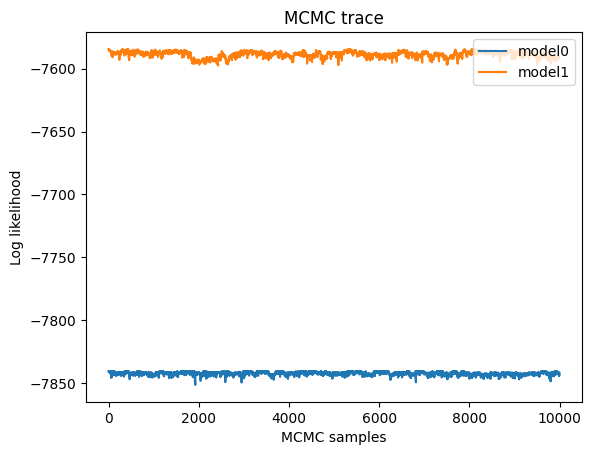

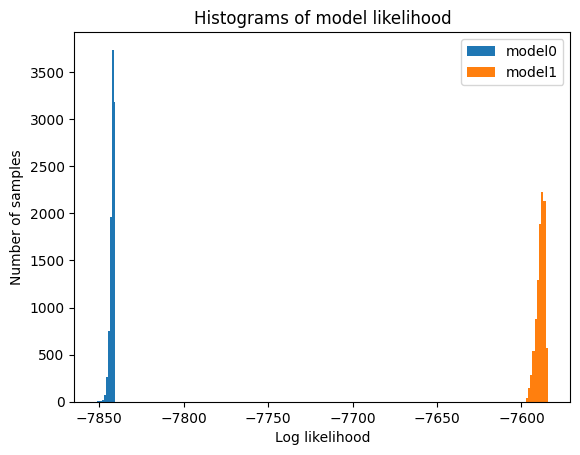

In [145]:
# for each subtype model
for s in range(N_S_max):
    # load pickle file (SuStaIn output) and get the sample log likelihood values
    pickle_filename_s = output_folder + '/pickle_files/' + dataset_name + '_subtype' + str(s) + '.pickle'
    pk = pandas.read_pickle(pickle_filename_s)
    samples_likelihood = pk["samples_likelihood"]
    
    # plot the values as a line plot
    fig0 = plt.figure(0)
    plt.plot(range(N_iterations_MCMC), samples_likelihood, label="model" + str(s))
    plt.legend(loc='upper right')
    plt.xlabel('MCMC samples')
    plt.ylabel('Log likelihood')
    plt.title('MCMC trace')
    
    # plot the values as a histogramp plot
    fig1 = plt.figure(1)
    plt.hist(samples_likelihood, label="model" + str(s))
    plt.legend(loc='upper right')
    plt.xlabel('Log likelihood')  
    plt.ylabel('Number of samples')  
    plt.title('Histograms of model likelihood')
fig0.savefig(output_folder+'/mcmc_trace.png')
fig1.savefig(output_folder+'/mcmc_histogram.png')


0
[1.]
[0]
1
[0.5659082 0.4340918]
[1 0]


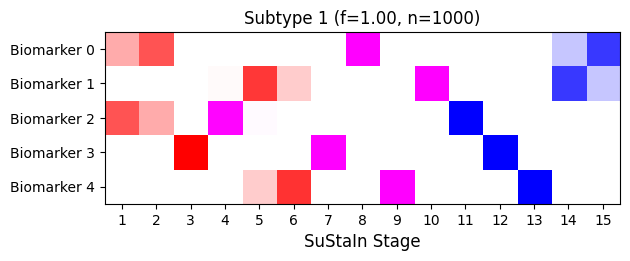

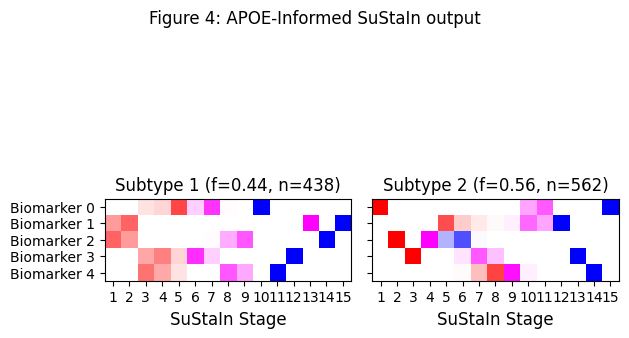

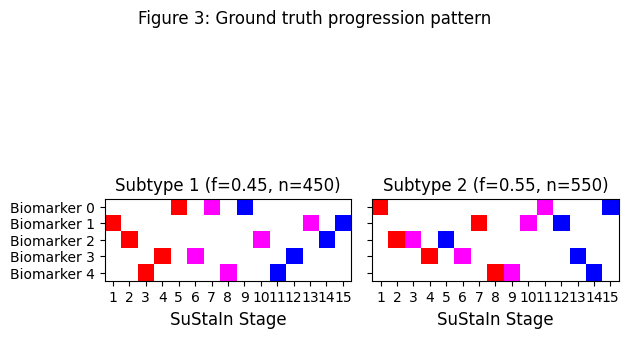

In [146]:

use_outlier = False
for s in range(N_S_max):
    print(s)
    #s = 1 # 1 split = 2 subtypes
    M = len(X_data) 

    # get the sample sequences and f
    pickle_filename_s = output_folder + '/pickle_files/' + dataset_name + '_subtype' + str(s) + '.pickle'
    pk = pandas.read_pickle(pickle_filename_s)
    samples_sequence = pk["samples_sequence"]
    samples_f = pk["samples_f"]
    ml_f_EM = pk["ml_f_EM"]
    print(ml_f_EM)
    if use_outlier:
        subtype_order = np.argsort(ml_f_EM[:-1])
    else:
        subtype_order = np.argsort(ml_f_EM)
    print(subtype_order)
    # use this information to plot the positional variance diagrams
    tmp=ZscoreSustain_APOE4._plot_sustain_model(sustain_input,samples_sequence,samples_f,M,subtype_order=subtype_order,biomarker_labels=BiomarkerNames)
    plt.savefig(output_folder + f"/pos_var_diagrams{s}.png")
_ = plt.suptitle('Figure 4: APOE-Informed SuStaIn output')

# Output a figure showing the ground truth
gt_sequence = gt_ordering
gt_f        = gt_fractions
temp_gt_sequence = np.tile(np.reshape(gt_sequence,(gt_sequence.shape[0],gt_sequence.shape[1],1)),100)
temp_gt_f = np.asarray(gt_f).reshape(len(gt_f),1)
dynamic_gt_order = np.arange(gt_sequence.shape[0])
ZscoreSustain_APOE4._plot_sustain_model(sustain_input,temp_gt_sequence,temp_gt_f,M,subtype_order=dynamic_gt_order)
_ = plt.suptitle('Figure 3: Ground truth progression pattern')


# Metrics for parameter recovery

In [ ]:
# Sequence recovery 

print(gt_ordering)
print(ml_sequence_EM)

subtype_ordering = np.argsort(ml_f_EM)
subtype_ordering

ordered_sequences = ml_sequence_EM[subtype_ordering]
print(ordered_sequences)


from scipy.stats import kendalltau
def sequence_recovery(gt_sequences, predicted_sequences):
    N_S_gt = gt_sequences.shape[0]
    # Use np.argsort to convert sequences into ranks, since Kendall's tau measures order similarity, not absolute values
    kendal_tau = np.round(np.array([kendalltau(np.argsort(gt_sequences[s]), np.argsort(predicted_sequences[s])).statistic for s in range(N_S_gt)]),2)
    print('KendalTau corr per subtype',kendal_tau)
    print('Avg KTAU',np.mean(kendal_tau))
    return kendal_tau
sequence_recovery(gt_ordering,ordered_sequences)

# i cant remember why i transform into np.argsort before i calculate kendalltau

[[ 1.  2.  4.  3.  0.  8.  5.  9. 10.  7. 14. 13.  6. 12. 11.]
 [ 0.  2.  7.  3. 12.  8.  1.  4.  9.  6.  5. 11. 13. 14. 10.]]
[[ 0.  2.  3.  7.  1. 12.  8.  4.  9.  6.  5. 11. 13. 14. 10.]
 [ 2.  1.  4.  3.  0.  8.  5.  9.  7. 10. 14. 13.  6. 12. 11.]]
[[ 2.  1.  4.  3.  0.  8.  5.  9.  7. 10. 14. 13.  6. 12. 11.]
 [ 0.  2.  3.  7.  1. 12.  8.  4.  9.  6.  5. 11. 13. 14. 10.]]
KendalTau corr per subtype [0.96 0.94]
Avg KTAU 0.95


array([0.96, 0.94])

In [ ]:
# from scipy.stats import kendalltau
# import numpy as np

# def sequence_recovery(gt_sequences, predicted_sequences):
#     N_S_gt = gt_sequences.shape[0]
    
#     # FIX: Pass the sequence arrays directly. 
#     # scipy's kendalltau automatically converts raw sequence positions into ordinal ranks under the hood!
#     kendal_tau = np.round(np.array([
#         kendalltau(gt_sequences[s], predicted_sequences[s]).statistic 
#         for s in range(N_S_gt)
#     ]), 2)
    
#     print('KendalTau corr per subtype:', kendal_tau)
#     print('Avg KTAU:', np.round(np.mean(kendal_tau), 2))
#     return kendal_tau

# # Run it cleanly on your aligned sequences
# sequence_recovery(gt_ordering, ordered_sequences)

KendalTau corr per subtype: [0.89 0.49]
Avg KTAU: 0.69


array([0.89, 0.49])

In [170]:
# genetic parameters error

print('True genetic params',W_true_target)
print('Estimated genetic weights',ml_genetic_weights_EM)

# need to re-order subtypes as we did for sequences
ordered_ml_genetic_weights_EM = ml_genetic_weights_EM[subtype_order]
print(ordered_ml_genetic_weights_EM)

# heatmap of error
ordered_ml_genetic_weights_EM - W_true_target


True genetic params [[0.8  0.15 0.05]
 [0.1  0.3  0.6 ]]
Estimated genetic weights [[0.06177852 0.32119272 0.61702875]
 [0.87073571 0.12266778 0.00659651]]
[[0.87073571 0.12266778 0.00659651]
 [0.06177852 0.32119272 0.61702875]]


array([[ 0.07073571, -0.02733222, -0.04340349],
       [-0.03822148,  0.02119272,  0.01702875]])

In [ ]:
# error in fraction?

Run baseline SuStaIn to compare

In [147]:
dataset_name = 'simulated_data_baseline_SuStaIn'
output_folder = os.path.join(os.getcwd(), dataset_name)
sustain_bl = ZscoreSustain_APOE4(X_data,
                                Z_vals,
                                Z_max,
                                BiomarkerNames,
                                N_startpoints,
                                N_subtypes, 
                                N_iterations_MCMC, 
                                output_folder, 
                                dataset_name, 
                                False,
                                apoe4_status = y_genetics,
                                #apoe4_status = gender_status_array,
                                apoe_flag = False)

Running baseline SuStain


In [148]:
# delete previous pickle files
if os.path.exists(output_folder):
    shutil.rmtree(output_folder)

In [149]:
# make the output directory if it's not already created
if not os.path.isdir(output_folder):
    os.mkdir(output_folder)

In [150]:
ml_sequence_EM,     \
ml_f_EM,            \
ml_subtype,         \
prob_ml_subtype,    \
ml_stage,           \
prob_ml_stage,      \
prob_subtype_stage,         = sustain_bl.run_sustain_algorithm()

Failed to find pickle file: /Users/mihaelacroitor/apoe4_informed/simulated_data_baseline_SuStaIn/pickle_files/simulated_data_baseline_SuStaIn_subtype0.pickle. Running SuStaIn model for 0 subtype.
Finding ML solution to 1 cluster problem
EM converged in 2 iterations
EM converged in 3 iterations
EM converged in 4 iterations
EM converged in 3 iterations
EM converged in 3 iterations
EM converged in 3 iterations
EM converged in 3 iterations
EM converged in 2 iterations
EM converged in 3 iterations
EM converged in 3 iterations
EM converged in 3 iterations
EM converged in 3 iterations
EM converged in 4 iterations
EM converged in 3 iterations
EM converged in 3 iterations
Overall ML likelihood is -6767.453279480256


MCMC Iteration: 100%|██████████| 10000/10000 [00:05<00:00, 1878.53it/s]



   FINAL MODEL SUBTYPE COHORT FRACTIONS
 -> Subtype 1 Cohort Size: 100.00% of dataset

Failed to find pickle file: /Users/mihaelacroitor/apoe4_informed/simulated_data_baseline_SuStaIn/pickle_files/simulated_data_baseline_SuStaIn_subtype1.pickle. Running SuStaIn model for 1 subtype.
Splitting cluster 1 of 1
Reindexing
 + Resolving 2 cluster problem
EM converged in 4 iterations
EM converged in 3 iterations
EM converged in 8 iterations
EM converged in 3 iterations
EM converged in 3 iterations
EM converged in 7 iterations
EM converged in 4 iterations
EM converged in 3 iterations
EM converged in 7 iterations
EM converged in 3 iterations
EM converged in 3 iterations
EM converged in 7 iterations
EM converged in 3 iterations
EM converged in 3 iterations
EM converged in 7 iterations
EM converged in 3 iterations
EM converged in 4 iterations
EM converged in 7 iterations
EM converged in 3 iterations
EM converged in 3 iterations
EM converged in 8 iterations
EM converged in 4 iterations
EM converge

MCMC Iteration:   1%|          | 51/10000 [00:00<00:12, 804.05it/s]


KeyboardInterrupt: 

In [ ]:
# calculate actual max likelihood from simulated parameters

sustainData = sustain_bl._AbstractSustain__sustainData

true_max_lik,_ ,_, _, _ = sustain_bl._calculate_likelihood(sustainData, gt_ordering,gt_fractions)

print(true_max_lik)
# see how many startingpoints achieved that

# look at last model (N_S == true)
#s = N_subtypes - 1
s = 0
pickle_filename_s = output_folder + '/pickle_files/' + dataset_name + '_subtype' + str(s) + '.pickle'
print(pickle_filename_s)
pk = pandas.read_pickle(pickle_filename_s)
ml_likelihood_mat_EM = pk["ml_likelihood_mat_EM"]

# did any starting points converge?
max_indices = np.where(np.isclose(ml_likelihood_mat_EM, true_max_lik))[0]
occurrence_count = len(max_indices)
print(f" {occurrence_count} starting points converged to true max lik {true_max_lik}")
#print(f"Reached by startpoints:   {max_indices}")

# find max EM lik, and how many times it is reached;
max_val = np.max(ml_likelihood_mat_EM)
max_indices = np.where(np.isclose(ml_likelihood_mat_EM, max_val))[0]
occurrence_count = len(max_indices)
print(f"Maximum Likelihood Value: {max_val} reached by {occurrence_count} startingpoints")
#print(f"Reached by startpoints:   {max_indices}")

ml_sequence_EM = pk["ml_sequence_EM"]
ml_f_EM = pk["ml_f_EM"]
print('ML seq EM', ml_sequence_EM)
print('True simulated seq', gt_ordering)

em_likelihood_histories = pk["em_likelihood_histories"]
print('EM lik hist',em_likelihood_histories)



-6749.867582341902
/Users/mihaelacroitor/apoe4_informed/simulated_data_baseline_SuStaIn/pickle_files/simulated_data_baseline_SuStaIn_subtype0.pickle
 0 starting points converged to true max lik -6749.867582341902
Maximum Likelihood Value: -6765.649953442963 reached by 10 startingpoints
ML seq EM [[ 4.  1.  2.  3.  0.  9.  8.  6.  5.  7. 14. 11. 12. 10. 13.]]
True simulated seq [[ 1.  4.  9.  2.  6.  3.  0.  8. 14.  7. 12. 11.  5. 10. 13.]
 [ 4.  2.  3.  1.  0.  8.  5.  9. 13.  6. 11. 10. 14.  7. 12.]
 [ 3.  0.  5.  4.  1.  8. 13.  6.  2. 10.  9.  7. 12. 14. 11.]]
EM lik hist [[-6772.9235306  -6772.14920939 -6806.77551755 ... -6774.10389785
  -6768.40962243 -6767.18862706]
 [-6765.64995344 -6766.8022209  -6765.64995344 ... -6774.10389785
  -6765.64995344 -6765.64995344]
 [-6765.64995344 -6765.64995344 -6765.64995344 ...            nan
  -6765.64995344 -6765.64995344]
 ...
 [           nan            nan            nan ...            nan
             nan            nan]
 [           nan 

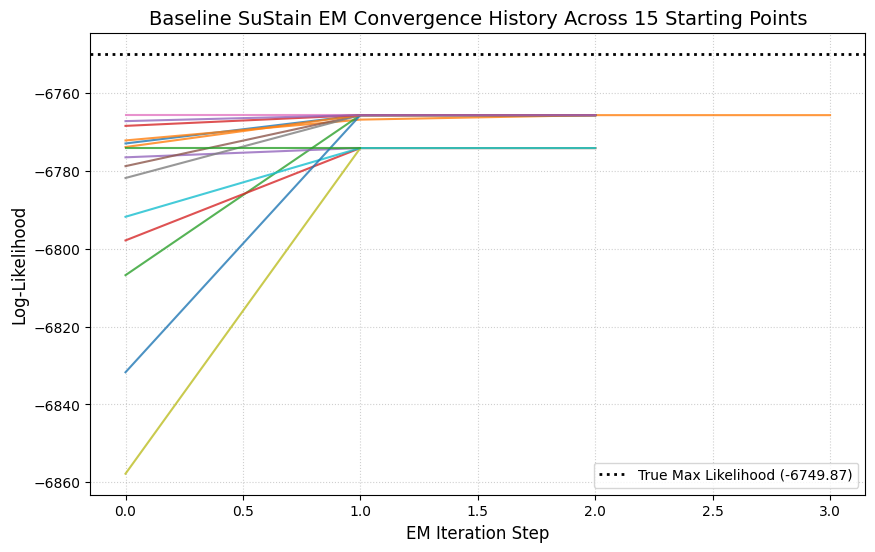

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Set up the figure size
plt.figure(figsize=(10, 6))

# 2. Plot the array directly
# Matplotlib plots each column (startpoint) as a separate colored line
plt.plot(em_likelihood_histories, linewidth=1.5, alpha=0.8)

# 3. Add your ground-truth maximum likelihood as a horizontal dotted line
# 'ls=":"' makes it dotted, 'color="black"' ensures high contrast, 'zorder=5' keeps it on top
plt.axhline(y=true_max_lik, color="black", linestyle=":", linewidth=2, label=f"True Max Likelihood ({true_max_lik:.2f})")


# 4. Add styling and descriptive labels
plt.xlabel("EM Iteration Step", fontsize=12)
plt.ylabel("Log-Likelihood", fontsize=12)
plt.title(f"Baseline SuStain EM Convergence History Across {em_likelihood_histories.shape[1]} Starting Points", fontsize=14)

plt.legend()
# 4. Clean up the grid presentation
plt.grid(True, linestyle=":", alpha=0.6)

# 5. Show the plot
plt.show()

In [ ]:
# Extract the active data container
sustainData = sustain_bl._AbstractSustain__sustainData

# Calculate the likelihood using the EXACT sequence and weights the model chose
test_loglike, _, _, _, _ = sustain_bl._calculate_likelihood(
    sustainData, 
    ml_sequence_EM,     # Your optimized sequence
    ml_f_EM            # Your optimized fractions
    #ml_genetic_weights_EM  # Pass the OPTIMIZED weights, not W_true!
)

print(f"Likelihood using Optimized EM Weights: {test_loglike:.2f}")
print(f"Final Plateau Level on your Plot:     {np.max(em_likelihood_histories[:,0])}")

Likelihood using Optimized EM Weights: -6765.65
Final Plateau Level on your Plot:     nan


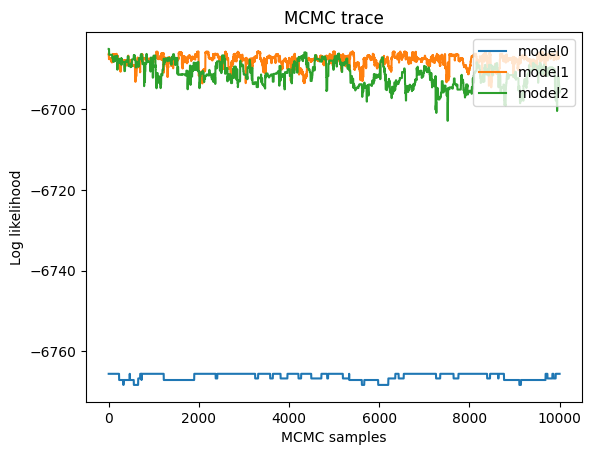

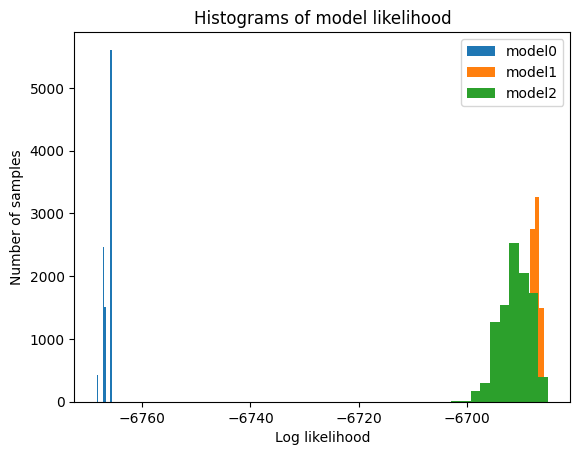

In [ ]:
# for each subtype model
for s in range(N_S_max):
    # load pickle file (SuStaIn output) and get the sample log likelihood values
    pickle_filename_s = output_folder + '/pickle_files/' + dataset_name + '_subtype' + str(s) + '.pickle'
    pk = pandas.read_pickle(pickle_filename_s)
    samples_likelihood = pk["samples_likelihood"]
    
    # plot the values as a line plot
    fig0 = plt.figure(0)
    plt.plot(range(N_iterations_MCMC), samples_likelihood, label="model" + str(s))
    plt.legend(loc='upper right')
    plt.xlabel('MCMC samples')
    plt.ylabel('Log likelihood')
    plt.title('MCMC trace')
    
    # plot the values as a histogramp plot
    fig1 = plt.figure(1)
    plt.hist(samples_likelihood, label="model" + str(s))
    plt.legend(loc='upper right')
    plt.xlabel('Log likelihood')  
    plt.ylabel('Number of samples')  
    plt.title('Histograms of model likelihood')
fig0.savefig(output_folder+'/mcmc_trace.png')
fig1.savefig(output_folder+'/mcmc_histogram.png')


0
[1.]
[0]
1
[0.57447774 0.42552226]
[1 0]
2
[0.58922883 0.22120975 0.18956142]
[2 1 0]


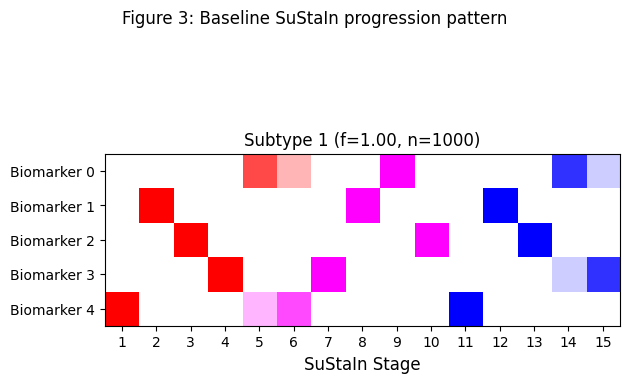

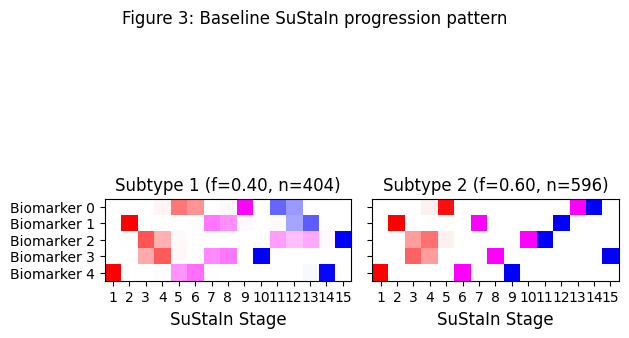

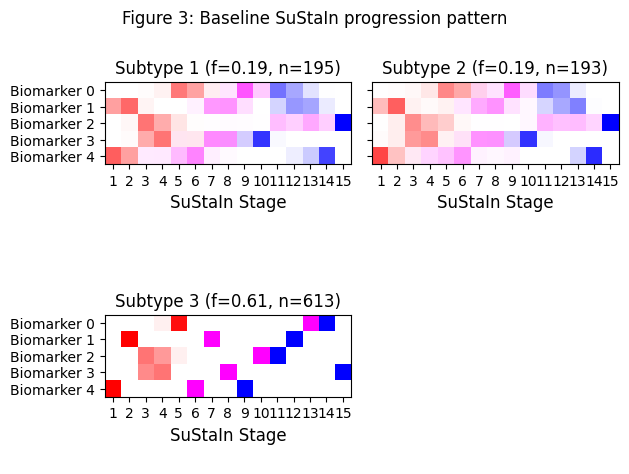

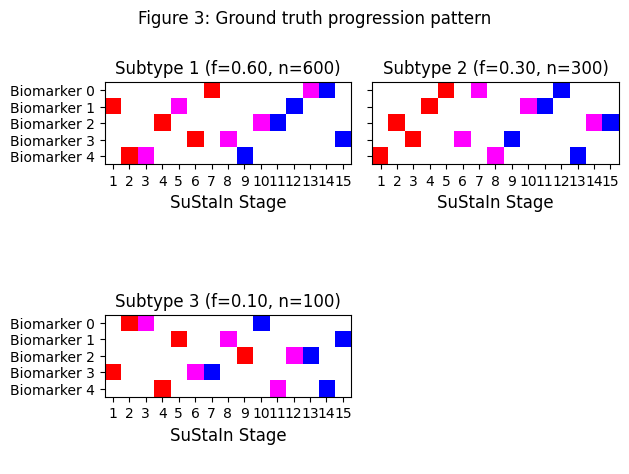

In [ ]:
# Let's plot positional variance diagrams to interpret the subtype progressions
use_outlier = False
for s in range(N_S_max):
    print(s)
    #s = 1 # 1 split = 2 subtypes
    M = len(X_data) 

    # get the sample sequences and f
    pickle_filename_s = output_folder + '/pickle_files/' + dataset_name + '_subtype' + str(s) + '.pickle'
    pk = pandas.read_pickle(pickle_filename_s)
    samples_sequence = pk["samples_sequence"]
    samples_f = pk["samples_f"]
    ml_f_EM = pk["ml_f_EM"]
    print(ml_f_EM)
    if use_outlier:
        subtype_order = np.argsort(ml_f_EM[:-1])
    else:
        subtype_order = np.argsort(ml_f_EM)
    print(subtype_order)
    # use this information to plot the positional variance diagrams
    tmp=ZscoreSustain_APOE4._plot_sustain_model(sustain_input,samples_sequence,samples_f,M,subtype_order=subtype_order,biomarker_labels=BiomarkerNames)
    plt.savefig(output_folder + f"/pos_var_diagrams{s}.png")
    _ = plt.suptitle('Figure 3: Baseline SuStaIn progression pattern')

# Output a figure showing the ground truth
gt_sequence = gt_ordering
gt_f        = gt_fractions
temp_gt_sequence = np.tile(np.reshape(gt_sequence,(gt_sequence.shape[0],gt_sequence.shape[1],1)),100)
temp_gt_f = np.asarray(gt_f).reshape(len(gt_f),1)
ZscoreSustain_APOE4._plot_sustain_model(sustain_input,temp_gt_sequence,temp_gt_f,M,subtype_order=(0,1,2))
_ = plt.suptitle('Figure 3: Ground truth progression pattern')

In [ ]:
print('Estimated seq',ml_sequence_EM)
print('True seq',gt_ordering)

Estimated seq [[ 4.  1.  2.  3.  0.  9.  8.  6.  5.  7. 14. 11. 12. 10. 13.]]
True seq [[ 1.  4.  9.  2.  6.  3.  0.  8. 14.  7. 12. 11.  5. 10. 13.]
 [ 4.  2.  3.  1.  0.  8.  5.  9. 13.  6. 11. 10. 14.  7. 12.]
 [ 3.  0.  5.  4.  1.  8. 13.  6.  2. 10.  9.  7. 12. 14. 11.]]
